# Laboratorio integrador: analizador de tendencias en noticias argentinas

**Duración estimada:** 1 hora

## Desafío
Vas a construir un sistema en Python que extraiga noticias de la web y las procese con `spaCy` para identificar entidades, verbos frecuentes, palabras clave y visualizaciones básicas.

## Resultados esperados
Al finalizar este laboratorio, vas a poder:
- extraer texto desde una URL periodística;
- encapsular análisis lingüístico en una clase reutilizable;
- generar visualizaciones a partir del texto procesado;
- integrar varias piezas en un pipeline simple de análisis de noticias.

## Modalidad de trabajo: pair programming con IA
En esta cátedra, `pair programming con IA` significa que la unidad de trabajo está formada por vos y un asistente de IA.

La IA puede ayudarte a:
- proponer estrategias;
- explicarte errores o mensajes del entorno;
- sugerir casos de prueba;
- comparar enfoques posibles;
- auditar código que ya escribiste.

La IA no reemplaza tu pensamiento. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu criterio.

## Bitácora breve de interacción con IA
Completá al menos una entrada por cada parte del laboratorio.

**Plantilla sugerida**
- Objetivo de la consulta.
- Prompt o pedido que hiciste.
- Qué te devolvió la IA.
- Qué conservaste.
- Qué corregiste o descartaste.
- Qué aprendiste del intercambio.


In [ ]:
# Instalamos las librerías necesarias en modo silencioso (-q)
!pip install spacy trafilatura pandas matplotlib wordcloud plotly -q
!python -m spacy download es_core_news_lg -q
!pip install nbformat --upgrade -q


In [2]:
# Importación de librerías
import spacy
import trafilatura
import pandas as pd
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import plotly.graph_objects as go

nlp = spacy.load("es_core_news_lg")
print("Modelo y librerías cargadas.")


Modelo y librerías cargadas.


## Parte 1: extracción de noticias (15 minutos)

**Objetivo:** construir una función que reciba una URL y devuelva un diccionario con el texto limpio de la noticia.

**Antes de escribir código, hace esta consulta a la IA:**
- Pedile dos estrategias posibles para descargar y extraer el contenido principal de una página.
- Elegí una y explicá por qué.

**Recordatorio:** si la IA te propone código, revisalo antes de incorporarlo.


urls_noticias = [
    "https://www.perfil.com/noticias/nea/peter-thiel-en-argentina-negocios-poder-y-senales-al-modelo-milei.phtml"
]

resultado = extraer_noticia(urls_noticias[0])

if resultado:
    print(f"URL: {resultado['url']}")
    print(f"Fecha: {resultado['fecha_extraccion']}")
    print(f"\nTexto (primeros 500 caracteres):")
    print(resultado['texto'][:500])
else:
    print("No se pudo extraer el texto")

In [3]:
def extraer_noticia(url):
    """
    Extrae el contenido principal de una noticia desde una URL.
    """
    try:
        # PASO 1: descargar el HTML de la página con trafilatura
        # descargado = None
        descargado = trafilatura.fetch_url(url)


        # PASO 2: extraer el texto principal a partir del HTML descargado
        # texto = None
        texto = trafilatura.extract(
            descargado,
            include_comments=False,   # excluye comentarios de usuarios
            no_fallback=False,        # intenta métodos alternativos si falla
            favor_recall=True,        # prioriza extraer más texto aunque haya ruido
            )

        if texto:
            return {
                'url': url,
                'texto': texto,
                'fecha_extraccion': datetime.now().strftime("%Y-%m-%d %H:%M")
            }

        print(f"Advertencia: no se pudo extraer texto de {url}")
        return None
    except Exception as e:
        print(f"Error procesando {url}: {e}")
        return None


# Reemplazá estas URLs por artículos reales cuando quieras probar la función.
urls_noticias = [
    "https://www.perfil.com/noticias/nea/peter-thiel-en-argentina-negocios-poder-y-senales-al-modelo-milei.phtml",
    "https://www.eldestapeweb.com/politica/thiel-en-argentina-que-piensa-y-que-planea-el-dueno-de-palantir-que-se-reunira-con-milei-2026423103234",
    "https://www.tiempoar.com.ar/ta_article/quien-es-peter-thiel-el-magnate-tecnocrata-que-se-reune-con-milei-en-casa-rosada-y-no-cree-en-la-democracia/",
]

# Sugerencia de prueba gradual:
# 1. Probá con una sola URL.
# 2. Verificá que el texto no sea None.
# 3. Recién después pasa a varias URLs.

In [4]:
# Probamos con la primera URL de la lista
"""resultado = extraer_noticia(urls_noticias)

if resultado:
    print(f"URL: {resultado['url']}")
    print(f"Fecha: {resultado['fecha_extraccion']}")
    print(f"\nTotal de caracteres extraídos: {len(resultado['texto'])}")
    print(f"\nTexto (primeros 500 caracteres):")
    print(resultado['texto'][:500])
else:
    print("No se pudo extraer el texto")"""

'resultado = extraer_noticia(urls_noticias)\n\nif resultado:\n    print(f"URL: {resultado[\'url\']}")\n    print(f"Fecha: {resultado[\'fecha_extraccion\']}")\n    print(f"\nTotal de caracteres extraídos: {len(resultado[\'texto\'])}")\n    print(f"\nTexto (primeros 500 caracteres):")\n    print(resultado[\'texto\'][:500])\nelse:\n    print("No se pudo extraer el texto")'

In [5]:
# Ahora que probamos las tres notas, vamos con las tres juntas:
# Procesamos las tres noticias
resultados_noticias = []

for url in urls_noticias:
    r = extraer_noticia(url)
    if r:
        resultados_noticias.append(r)
        print(f"✓ Extraída: {url[:50]}...")
    else:
        print(f"✗ Falló: {url[:50]}...")

print(f"\nTotal de noticias extraídas: {len(resultados_noticias)}")

✓ Extraída: https://www.perfil.com/noticias/nea/peter-thiel-en...
✓ Extraída: https://www.eldestapeweb.com/politica/thiel-en-arg...
✓ Extraída: https://www.tiempoar.com.ar/ta_article/quien-es-pe...

Total de noticias extraídas: 3


## Parte 2: análisis de texto con spaCy (20 minutos)

**Objetivo:** encapsular el análisis en una clase `AnalizadorNoticia`.

**Consulta sugerida a la IA antes de completar los métodos:**
- Pedile un mapa de responsabilidades para la clase.
- Pedile criterios para distinguir personas, organizaciones y lugares a partir de `ent.label_`.
- Después compara esa propuesta con la documentación o con las salidas del modelo.


El mapa de AnalizadorNoticia

Método:	                         Recibe:	         Hace:	                                          Devuelve:
__init__	                     texto + modelo	     procesa el texto con spaCy y guarda el Doc	      nada, inicializa el objeto
obtener_entidades()	             nada	             recorre doc.ents y clasifica por tipo	          diccionario con PER, ORG, LOC, OTROS
obtener_verbos_principales()	 n (opcional)	     filtra verbos, lematiza, cuenta frecuencias	  lista de tuplas (verbo, frecuencia)
obtener_estadisticas()	         nada	             cuenta tokens, oraciones, palabras únicas	      diccionario con métricas
extraer_frases_con_entidad()	 nombre de entidad	 recorre oraciones buscando la entidad	          lista de oraciones que la menciona




In [24]:
class AnalizadorNoticia:
    def __init__(self, texto, nlp_model):
        """
        Inicializa el analizador con un texto y un modelo de spaCy ya cargado.
        """
        self.texto_original = texto
        self.nlp = nlp_model

        # PASO 3: procesa el texto y guarda el objeto Doc en self.doc
        self.doc = nlp_model(texto)

    def obtener_entidades(self):
        """Devuelve un diccionario con entidades agrupadas por tipo."""
        entidades = {
            'PERSONAS': [],
            'ORGANIZACIONES': [],
            'LUGARES': [],
            'OTROS': []
        }
        
        # Diccionario de normalización
        normalizacion = {
            'Peter Thiel': 'Thiel',
            'Javier Milei': 'Milei',
            'la Argentina': 'Argentina',
            'los Estados Unidos': 'Estados Unidos',
            'Donald Trump': 'Trump', 
        }

        for ent in self.doc.ents:
            # Normaliza el texto antes de clasificar
            texto_entidad = normalizacion.get(ent.text, ent.text) # para modificar el diccionario

            if ent.label_ == 'PER':
                entidades['PERSONAS'].append(texto_entidad)
            elif ent.label_ == 'ORG':
                entidades['ORGANIZACIONES'].append(texto_entidad)
            elif ent.label_ == 'LOC':
                entidades['LUGARES'].append(texto_entidad)
            else:
                entidades['OTROS'].append(texto_entidad)

        return entidades



    # PASO 4: itera sobre self.doc.ents y clasifica cada entidad.
    # Pista: revisa valores como 'PER', 'ORG', 'LOC' y 'MISC'.
    """for ent in self.doc.ents:
        if ent.label_ == 'PER':
            entidades['PERSONAS'].append(ent.text)
        elif ent.label_ == 'ORG':
            entidades['ORGANIZACIONES'].append(ent.text)
        elif ent.label_ == 'LOC':
            entidades['LUGARES'].append(ent.text)
        else:
            entidades['OTROS'].append(ent.text)

    return entidades"""

    def obtener_verbos_principales(self, n=10):
        """Devuelve una lista de tuplas (verbo_lematizado, frecuencia)."""
        # PASO 5: filtra verbos, lematizalos y contalos con Counter.
        verbos = [
            token.lemma_.lower()
            for token in self.doc
            if token.pos_ == 'VERB' and not token.is_stop
        ]
        frecuencias = Counter(verbos)
        return frecuencias.most_common(n)

    def obtener_estadisticas(self):
        """Calcula estadísticas descriptivas básicas del texto."""
        # PASO 6: calcula estas métricas a partir de self.doc.
        total_tokens = len(self.doc)
        total_oraciones = len(list(self.doc.sents))
        palabras_unicas = len(set(
            token.text.lower()
            for token in self.doc
            if token.is_alpha
        ))
        #total_tokens = 0
        #total_oraciones = 0
        #palabras_unicas = 0

        return {
            'total_tokens': total_tokens,
            'total_oraciones': total_oraciones,
            'palabras_unicas': palabras_unicas,
            'longitud_promedio_oracion': round(total_tokens / total_oraciones, 1),
        }

    def extraer_frases_con_entidad(self, nombre_entidad):
        """Devuelve oraciones que contengan una entidad específica."""
        oraciones = []

        # PASO 7: recorre self.doc.sents y guarda las oraciones
        # que mencionen la entidad solicitada.
        for oracion in self.doc.sents:
            if nombre_entidad.lower() in oracion.text.lower():
                oraciones.append(oracion.text)
        return oraciones

# Probamos con el texto de prueba
"""texto_prueba = (
    "El presidente Javier Milei estuvo el martes en la provincia de Santa Fe para inaugurar "
    "una nueva planta de procesamiento de soja. La compañía AgroTech Argentina anunció una "
    "inversión de 80 millones de dólares. Mariana López, gerente general, explicó que el "
    "proyecto generará 300 puestos de trabajo."
)

# Probamos con el texto de prueba

# Descomenta estas líneas cuando completes al menos __init__ y dos métodos.
analizador_prueba = AnalizadorNoticia(texto_prueba, nlp)
print(analizador_prueba.obtener_entidades())
print(analizador_prueba.obtener_verbos_principales())
print(analizador_prueba.obtener_estadisticas())
"""

'texto_prueba = (\n    "El presidente Javier Milei estuvo el martes en la provincia de Santa Fe para inaugurar "\n    "una nueva planta de procesamiento de soja. La compañía AgroTech Argentina anunció una "\n    "inversión de 80 millones de dólares. Mariana López, gerente general, explicó que el "\n    "proyecto generará 300 puestos de trabajo."\n)\n\n# Probamos con el texto de prueba\n\n# Descomenta estas líneas cuando completes al menos __init__ y dos métodos.\nanalizador_prueba = AnalizadorNoticia(texto_prueba, nlp)\nprint(analizador_prueba.obtener_entidades())\nprint(analizador_prueba.obtener_verbos_principales())\nprint(analizador_prueba.obtener_estadisticas())\n'

In [25]:
# Cargamos un modelo mejorado con EntityRuler
nlp_mejorado = spacy.load("es_core_news_lg")

# Insertamos el EntityRuler ANTES del ner
config = {"overwrite_ents": True}
ruler = nlp_mejorado.add_pipe("entity_ruler", config=config, before="ner")

# Patrones basados en los errores que detectamos en las tres notas
patrones_locales = [
    # Personas
    {"label": "PER", "pattern": "Peter Thiel"},
    {"label": "PER", "pattern": "Thiel"},
    {"label": "PER", "pattern": "Javier Milei"},
    {"label": "PER", "pattern": "Milei"},
    # Organizaciones tecnológicas
    {"label": "ORG", "pattern": "Palantir"},
    {"label": "ORG", "pattern": "PayPal"},
    {"label": "ORG", "pattern": "Facebook"},
    {"label": "ORG", "pattern": "Cambridge Analytica"},
    {"label": "ORG", "pattern": "BlackRock"},
    {"label": "ORG", "pattern": "LinkedIn"},
    {"label": "ORG", "pattern": "X.com"},
    # Organizaciones institucionales
    {"label": "ORG", "pattern": "CIA"},
    {"label": "ORG", "pattern": "Pentágono"},
    {"label": "ORG", "pattern": "Casa Rosada"},
    {"label": "ORG", "pattern": "Silicon Valley"},
    {"label": "ORG", "pattern": "Wall Street"},
]

ruler.add_patterns(patrones_locales)
print(f"Pipeline modificado: {nlp_mejorado.pipe_names}")

Pipeline modificado: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'entity_ruler', 'ner']


In [26]:
# Recreamos los analizadores con el modelo mejorado
medios = ['Perfil', 'El Destape', 'Tiempo Argentino']

analizadores_mejorados = [
    AnalizadorNoticia(r['texto'], nlp_mejorado)
    for r in resultados_noticias
]

# Comparamos entidades antes y después
for medio, analizador in zip(medios, analizadores_mejorados):
    print(f"\n{'='*50}")
    print(f"MEDIO: {medio}")
    print(f"{'='*50}")

    print("\n--- ENTIDADES ---")
    for tipo, lista in analizador.obtener_entidades().items():
        if lista:
            print(f"  {tipo}: {list(set(lista))}")


MEDIO: Perfil

--- ENTIDADES ---
  PERSONAS: ['Milei', 'Thiel']
  ORGANIZACIONES: ['Cofundador de', 'Facebook', 'Amazon', 'PayPal']
  LUGARES: ['Patagonia', 'Estado.', 'Gobierno de', 'Ciudad de Buenos Aires', 'Argentina', 'Corrientes', 'Estado', 'Gobierno', 'en Estados Unidos']
  OTROS: ['IA', 'Ese punto', 'Negocios', 'Por otro', 'Detrás de la visita', 'Por un lado', 'La llegada de figuras']

MEDIO: El Destape

--- ENTIDADES ---
  PERSONAS: ['Greta Thunberg', 'Michael Kratsios', 'Nicolás Maduro', 'Pausa', 'Leviatán', 'In-Q-Tel', 'Curtis Yarvin', 'JD Vance', 'Él', 'Ross Douthat', 'Girard', 'Arne Panula', 'Patricia Bullrich', 'Josemaría Escrivá de Balaguer', 'Alec Oxenford', 'Jacob Helberg', 'Milton Friedman', 'Schmitt', 'Milei', 'Eisenhower', 'Elon Musk', 'Karp', 'Strauss', 'David Sacks', 'Leo Strauss', 'Thiel', 'Roelof Botha', 'René Girard', 'heil Hitler', 'Douthat', 'Oxenford', 'Peter', 'Musk', 'Financió', 'Nick Clegg', 'Praxis', 'Klaus', 'Anticristo', 'Alex Karp', 'Sostené', 'Trump'

In [27]:
medios = ['Perfil', 'El Destape', 'Tiempo Argentino']

analizadores_mejorados = [
    AnalizadorNoticia(r['texto'], nlp_mejorado)
    for r in resultados_noticias
]

for medio, analizador in zip(medios, analizadores_mejorados):
    print(f"\n{'='*50}")
    print(f"MEDIO: {medio}")
    print(f"{'='*50}")

    print("\n--- ESTADÍSTICAS ---")
    for k, v in analizador.obtener_estadisticas().items():
        print(f"  {k}: {v}")

    print("\n--- ENTIDADES ---")
    for tipo, lista in analizador.obtener_entidades().items():
        if lista:
            print(f"  {tipo}: {list(set(lista))}")

    print("\n--- VERBOS PRINCIPALES ---")
    for verbo, freq in analizador.obtener_verbos_principales():
        print(f"  {verbo}: {freq}")


MEDIO: Perfil

--- ESTADÍSTICAS ---
  total_tokens: 562
  total_oraciones: 19
  palabras_unicas: 243
  longitud_promedio_oracion: 29.6

--- ENTIDADES ---
  PERSONAS: ['Milei', 'Thiel']
  ORGANIZACIONES: ['Cofundador de', 'Facebook', 'Amazon', 'PayPal']
  LUGARES: ['Patagonia', 'Estado.', 'Gobierno de', 'Ciudad de Buenos Aires', 'Argentina', 'Corrientes', 'Estado', 'Gobierno', 'en Estados Unidos']
  OTROS: ['IA', 'Ese punto', 'Negocios', 'Por otro', 'Detrás de la visita', 'Por un lado', 'La llegada de figuras']

--- VERBOS PRINCIPALES ---
  combinar: 2
  entrar: 2
  volver: 2
  aparecer: 2
  buscar: 2
  desembarcar: 1
  funcionar: 1
  posicionar: 1
  mantener: 1
  incluir: 1

MEDIO: El Destape

--- ESTADÍSTICAS ---
  total_tokens: 4201
  total_oraciones: 179
  palabras_unicas: 1309
  longitud_promedio_oracion: 23.5

--- ENTIDADES ---
  PERSONAS: ['Greta Thunberg', 'Michael Kratsios', 'Nicolás Maduro', 'Pausa', 'Leviatán', 'In-Q-Tel', 'Curtis Yarvin', 'JD Vance', 'Él', 'Ross Douthat', '

## Parte 3: visualización de resultados (20 minutos)

**Objetivo:** construir dos visualizaciones simples a partir del texto procesado.

**Consulta sugerida a la IA:**
- Pedile criterios para decidir qué tokens conviene excluir de una nube de palabras.
- Pedile una propuesta de estructura para un gráfico de barras horizontal.
- Después revisa si esas sugerencias se ajustan a tu caso.


In [28]:
def crear_nube_palabras(doc_procesado):
    """Crea y muestra una nube de palabras a partir de un Doc de spaCy."""
    # PASO 8: extrae lemas relevantes.
    # Pista: filtra stopwords, puntuación y tokens no alfabéticos.
    palabras_relevantes = [
        token.lemma_.lower()
        for token in doc_procesado
        if token.is_alpha and not token.is_stop and len(token.text) > 2
    ]

    texto_limpio = ' '.join(palabras_relevantes)

    if texto_limpio:
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            collocations=False,
        ).generate(texto_limpio)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.show()
    else:
        print("No hay suficientes palabras relevantes para generar la nube.")


def visualizar_entidades_mas_comunes(entidades_dict, n=10):
    """Muestra un gráfico de barras con las entidades más frecuentes."""
    # PASO 9: combina las listas del diccionario y contá frecuencias.
    todas_entidades = []
    for tipo, lista in entidades_dict.items():
        todas_entidades.extend(lista)
    
    
    frecuencias = Counter(todas_entidades)
    entidades_comunes = frecuencias.most_common(n)

    if not entidades_comunes:
        print("No se encontraron entidades para visualizar.")
        return

    # PASO 10: prepara los datos y construí un gráfico horizontal con Plotly.
    # Pista: podés usar go.Bar(..., orientation='h').
    entidades = [e[0] for e in entidades_comunes]
    conteos = [e[1] for e in entidades_comunes]

    fig = go.Figure(go.Bar(
        x=conteos,
        y=entidades,
        orientation='h',
        marker_color='steelblue'
    ))

    fig.update_layout(
        title='Entidades más frecuentes',
        xaxis_title='Frecuencia',
        yaxis_title='Entidad',
        height=500,
        yaxis=dict(autorange='reversed')
    )

    fig.show()



NUBE DE PALABRAS — Perfil


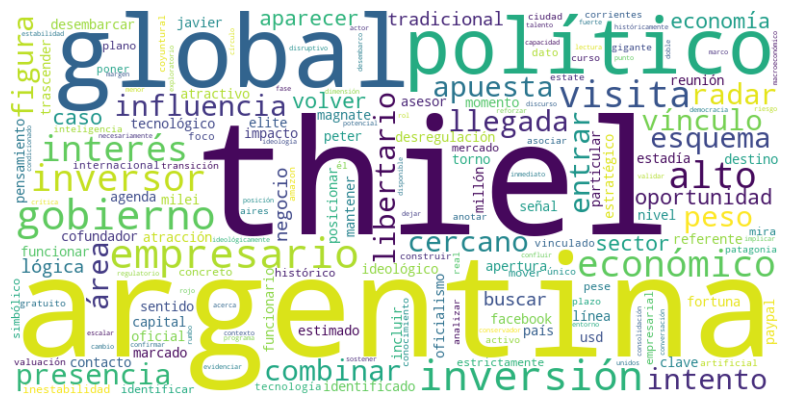


ENTIDADES MÁS COMUNES — Perfil



NUBE DE PALABRAS — El Destape


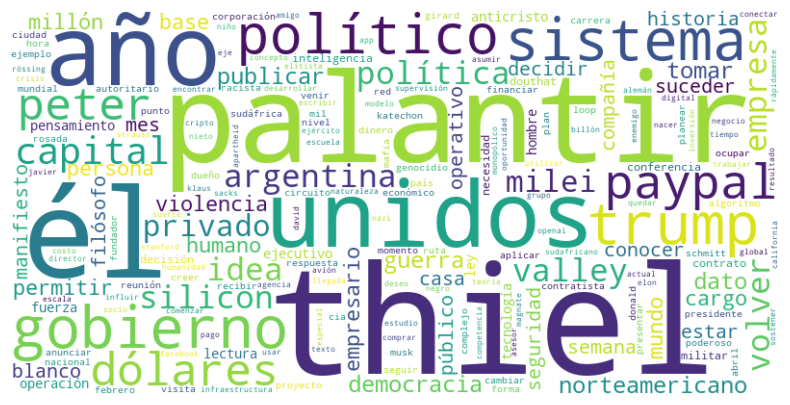


ENTIDADES MÁS COMUNES — El Destape



NUBE DE PALABRAS — Tiempo Argentino


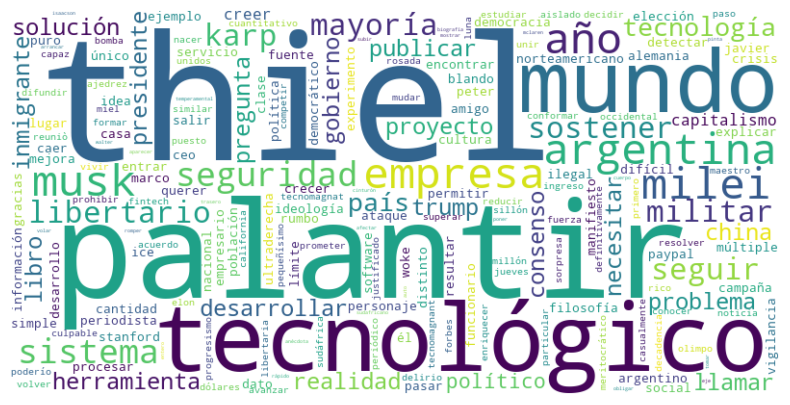


ENTIDADES MÁS COMUNES — Tiempo Argentino


In [29]:
medios = ['Perfil', 'El Destape', 'Tiempo Argentino']

for medio, analizador in zip(medios, analizadores_mejorados):
    print(f"\n{'='*50}")
    print(f"NUBE DE PALABRAS — {medio}")
    print(f"{'='*50}")
    crear_nube_palabras(analizador.doc)

    print(f"\nENTIDADES MÁS COMUNES — {medio}")
    visualizar_entidades_mas_comunes(analizador.obtener_entidades())

## Parte 4: integración en un pipeline (10 minutos)

**Objetivo:** integrar extracción, análisis y reporte agregado para varias noticias.

En esta parte conviene trabajar de menor a mayor:
1. probá con una sola URL;
2. verificá que el texto se extraiga;
3. recién después procesa una lista.


In [30]:
class AnalizadorTendencias:
    def __init__(self, lista_urls):
        self.urls = lista_urls
        self.noticias_data = []
        self.analizadores = []
        #self.nlp = spacy.load("es_core_news_lg")
        self.nlp = nlp_mejorado  # para usar el modelo con EntityRuler

    def procesar_todas(self):
        """Orquesta la extracción y el análisis de todas las URLs."""
        print(f"Iniciando procesamiento de {len(self.urls)} URLs...")
        for url in self.urls:
            # PASO 11: usa extraer_noticia(url).
            noticia = extraer_noticia(url)

            if noticia:
                self.noticias_data.append(noticia)
                # PASO 12: crea un AnalizadorNoticia y guardalo en self.analizadores.
                analizador = AnalizadorNoticia(noticia['texto'], self.nlp)
                self.analizadores.append(analizador)
                print(f"✓ Procesada: {url[:50]}...")
            else:
                print(f"✗ Falló: {url[:50]}...")
                
        #print("Procesamiento completado.")
        print(f"\nProcesamiento completado: {len(self.analizadores)} noticias.")


    def generar_reporte_agregado(self, n=15):
        """Genera un reporte consolidado de todas las noticias procesadas."""
        if not self.analizadores:
            print("No hay noticias procesadas para generar un reporte.")
            return

        todas_las_entidades = {
            "PERSONAS": [],
            "ORGANIZACIONES": [],
            "LUGARES": [],
            "OTROS": []
        }
        todos_los_verbos = []

        # PASO 13: recorre self.analizadores y acumula entidades y verbos.
        for analizador in self.analizadores:
            entidades = analizador.obtener_entidades()
            for tipo, lista in entidades.items():
                todas_las_entidades[tipo].extend(lista)

            verbos = analizador.obtener_verbos_principales(n=n)
            todos_los_verbos.extend([v[0] for v in verbos])

        print(f"\n--- REPORTE AGREGADO DE {len(self.analizadores)} NOTICIAS ---")
        print("\n--- ENTIDADES MAS COMUNES ---")
        visualizar_entidades_mas_comunes(todas_las_entidades, n=n)

        print("\n--- VERBOS MAS COMUNES ---")
        frecuencias_verbos = Counter(todos_los_verbos)
        print(frecuencias_verbos.most_common(n))

# Instanciamos el pipeline completo
# Descomenta cuando completes la mayor parte del laboratorio.
pipeline = AnalizadorTendencias(urls_noticias)
pipeline.procesar_todas()
# Generamos el reporte agregado de las tres notas
pipeline.generar_reporte_agregado()


Iniciando procesamiento de 3 URLs...
✓ Procesada: https://www.perfil.com/noticias/nea/peter-thiel-en...
✓ Procesada: https://www.eldestapeweb.com/politica/thiel-en-arg...
✓ Procesada: https://www.tiempoar.com.ar/ta_article/quien-es-pe...

Procesamiento completado: 3 noticias.

--- REPORTE AGREGADO DE 3 NOTICIAS ---

--- ENTIDADES MAS COMUNES ---



--- VERBOS MAS COMUNES ---
[('volver', 2), ('publicar', 2), ('permitir', 2), ('seguir', 2), ('creer', 2), ('combinar', 1), ('entrar', 1), ('aparecer', 1), ('buscar', 1), ('desembarcar', 1), ('funcionar', 1), ('posicionar', 1), ('mantener', 1), ('incluir', 1), ('trascender', 1)]


## Entregables, criterios de evaluación y cierre

### Entregables sugeridos
- Las funciones y clases completadas.
- Al menos una prueba con una noticia real.
- Una bitácora breve de interacción con IA.
- Una justificación corta sobre una decisión que tomaste a partir de una sugerencia de la IA y otra que descartaste.

### Criterios de evaluación
- **Funcionamiento técnico:** que el pipeline complete tareas básicas de extracción, análisis y visualización.
- **Juicio crítico:** que puedas explicar por qué elegiste una estrategia y no otra.
- **Uso de IA con criterio:** que la IA aparezca como apoyo de exploración, no como reemplazo del razonamiento.
- **Proceso documentado:** que la bitácora muestre qué tomaste, qué corregiste y qué descartaste.
- **Claridad del código:** que las funciones y clases sean legibles y consistentes.

### Checklist antes de entregar
- Probaste cada parte por separado antes de integrar todo?
- Podés explicar qué hace cada función principal?
- Tu bitácora muestra intervención humana real sobre los outputs de IA?
- Hay al menos un ejemplo donde corregiste o descartaste una sugerencia de la IA?

Si respondiste que sí a estas preguntas, tu laboratorio ya está alineado con la propuesta pedagógica de la cátedra.
